# Imports

In [1]:
import pandas as pd
import numpy as np
from langchain_openai import AzureChatOpenAI
import json
from pathlib import Path
from datetime import datetime as dt

# EDA

In [2]:
# # read data and rename columns
# df = pd.read_csv("data/requirements_full.csv")
# df.columns = ["requirement", "s1", "s2", "s3", "s4", "s5", "s6"]
df = pd.read_excel("data/requirements.xlsx")

[Text(0, 0, '82'),
 Text(0, 0, '92'),
 Text(0, 0, '29'),
 Text(0, 0, '36'),
 Text(0, 0, '54')]

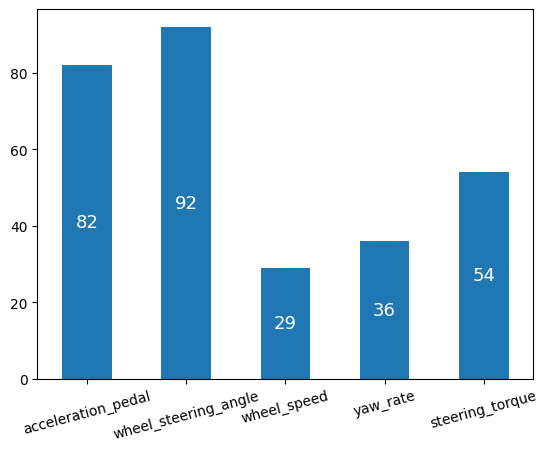

In [59]:
ax = df.drop(columns="requirement").sum().plot.bar(rot=15)
ax.bar_label(ax.containers[0], label_type="center", c="white", fontsize=13)

In [4]:
# make sure all columns except the first one are binary
for c in df.columns[1:]:
    assert df[c].drop_duplicates().shape[0] == 2

# Find Examples

In [5]:
# collect used examples to exclude from test dataset
indexes_to_drop = []

In [6]:
# collect examples with single fault
examples = {}

for c in df.columns[1:]:
    examples[c] = {}
    i = df.loc[ (df[c] == 1) & (df[df.columns[1:][df.columns[1:]!=c]].sum(axis=1) == 0) ].sample(1)
    indexes_to_drop.append(i.index)
    i = i.values[0]
    examples[c]["req"] = i[0]
    examples[c]["vec"] = "[" + ",".join(map(str, i[1:])) + "]"

In [7]:
# collect examples with multiple faults
examples_multiple = {}

t = df.loc[df[df.columns[1:]].sum(axis=1) == 2]
idx = t.drop(columns="requirement").drop_duplicates().index
indexes_to_drop.append(idx)
t = df.iloc[idx, :].values

for r in t:
    c = "&".join(df.columns[1:][r[1:]==1])
    examples_multiple[c] = {}
    examples_multiple[c]["req"] = r[0]
    examples_multiple[c]["vec"] = "[" + ",".join(map(str, r[1:])) + "]"

In [8]:
# add both single and multiple into one place
examples.update(examples_multiple)

In [9]:
# join all examples in a text format to add to prompt
examples_txt = ""

for e in examples.values():
    examples_txt += f"Requirement: {e['req']}\n"
    examples_txt += f"Vector: {e['vec']}\n"
    examples_txt += "\n"

In [10]:
print("\n".join(examples_txt.split("\n")[:5]))

Requirement: The ECU must perform self-diagnostics to ensure its health and operational integrity at startup and during operation
Vector: [1,0,0,0,0]

Requirement: In case of power steering failure, the system should allow for manual steering control with an acceptable increase in effort
Vector: [0,1,0,0,0]


In [11]:
# drop indexes used in examples
indexes_to_drop = np.concatenate(indexes_to_drop)
df.drop(index=indexes_to_drop, inplace=True)
df.reset_index(drop=True, inplace=True)

# LLM

In [12]:
from prompts.SystemPrompts import SystemPrompt
from prompts.Sensors import Sensors
from prompts.UserPromptBulk import UserPromptBulk

In [13]:
# print(SystemPrompt.format(sensors=Sensors,examples=examples_txt))

In [20]:
# llm
llm = AzureChatOpenAI(
    deployment_name="gpt-35",
    # deployment_name="gpt-4",
    temperature=0.0,
    # max_tokens=16_385
)

In [21]:
# system prompt
messages = [
    {'role': 'system',
     'content': SystemPrompt.format(sensors=Sensors,examples=examples_txt)}
]

In [22]:
# select random instance
N_REQS = 30
# SAMPLE_TYPE = "first"
SAMPLE_TYPE = "random"

if N_REQS > df.shape[0]: N_REQS = df.shape[0]

if SAMPLE_TYPE == "random": instances = df.sample(N_REQS)
else: instances = df.iloc[:N_REQS,:]

idx = instances.index
req = instances["requirement"].tolist()
vec = instances.iloc[:, 1:].apply(lambda x: "[" + ",".join(map(str, x)) + "]", axis=1).to_list()

In [23]:
reqs = ""

for i, r in enumerate(req):
    reqs += f"Requirement {i}: {r}.\n"

# print(reqs)

In [24]:
# add user prompt
messages.append({"role":"user", "content":UserPromptBulk.format(req=reqs)})

In [25]:
# run LLM
response = llm.invoke(messages)
messages.append({"role":"assistant", "content":response.content})

In [26]:
def parse_result(messages):
    '''Parse the LLM result'''
    lines = messages[-1]["content"].split("\n")
    return [*map(lambda s: s.split(":")[-1].replace(" ", ""), lines)]

In [27]:
# number of tokens
response.response_metadata["token_usage"]

{'completion_tokens': 480, 'prompt_tokens': 1558, 'total_tokens': 2038}

# Save conversation

In [35]:
# save conversation and metadata
time = dt.now()

conv_file_name = "chats/conv_{model}{kind}_{time}.json"
conv_file_name=conv_file_name.format(model=llm.deployment_name,
                      time=time.strftime('%d.%m.%Y-%H:%M:%S'),
                      kind=f"_{idx.to_list()[0]}" if len(idx)==1 else f"_multi-{SAMPLE_TYPE}-{len(req)}")

conv_file = Path().cwd() / conv_file_name
conv_file.parent.mkdir(exist_ok=True)
conv_file.touch()

correct_ids = idx[[i for i, (a, b) in enumerate(zip(parse_result(messages), vec)) if a == b]].to_list()
incorrect_ids = idx[[i for i, (a, b) in enumerate(zip(parse_result(messages), vec)) if a != b]].to_list()

with conv_file.open("w") as f:
    json.dump({'messages': messages,
               'true_solution': vec,
               'correct_ids': correct_ids,
               'incorrect_ids': incorrect_ids,
               'number_of_requirements': len(idx),
               'accuracy': round(len(correct_ids) / len(idx), 4),
               'examples_ids': indexes_to_drop.tolist(),
               'number_of_examples': len(indexes_to_drop),
               'target_id': idx.to_list(),
               'token_usage': response.response_metadata["token_usage"]
            },
            f, indent=4)